

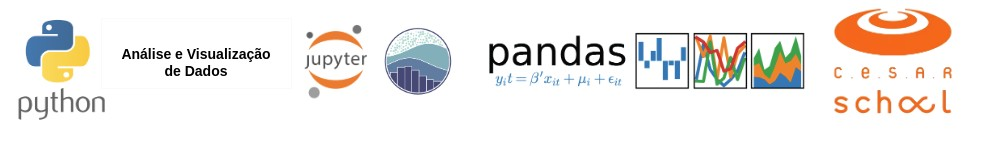



# **Explorando Texto e Nomes de Músicas 🎵🔍**

**Professor:** Matheus Soares msl3@cesar.school

**Grupo 05**

**Alunos:** SEVERINO HENRIQUE DE ARAUJO NETO | MATEUS ALBUQUERQUE FALCAO | LAURA SILVA SOARES DE MELO | THIAGO ROBERTO CAVALCANTI PIMENTEL | RAFAEL FERREIRA SALGADO

## BIBLIOTECAS

In [3]:
# 📥 Importação das Bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from IPython.display import display


# Configuração para exibir melhor os dados
pd.set_option('display.float_format', '{:.2f}'.format)

----------------------------------------------------------------------------------------------------------------------------------------------

## EXPLORAÇÃO DOS DADOS

In [4]:
# Carregar dataset
path = "https://raw.githubusercontent.com/devjaynemorais/modelos_descritivos_curso/main/Aula%2001/dados/dataset_lyrics.csv"
df = pd.read_csv(path, encoding='utf-8')

df.head(10)

,cantorId,cantorNome,musicaNome,letra
0,0,10000-maniacs,More Than This,I could feel at the time. There was no way of ...
1,0,10000-maniacs,Because The Night,"Take me now, baby, here as I am. Hold me close..."
2,0,10000-maniacs,These Are Days,These are. These are days you'll remember. Nev...
3,0,10000-maniacs,A Campfire Song,"A lie to say, ""O my mountain has coal veins an..."
4,0,10000-maniacs,Everyday Is Like Sunday,Trudging slowly over wet sand. Back to the ben...
5,0,10000-maniacs,Don't Talk,"Don't talk, I will listen. Don't talk, you kee..."
6,0,10000-maniacs,Across The Fields,"Well they left then in the morning, a hundred ..."
7,0,10000-maniacs,Planned Obsolescence,[ music: Dennis Drew/lyric: Natalie Merchant ]...
8,0,10000-maniacs,Rainy Day,On bended kneeI've looked through every window...
9,0,10000-maniacs,Anthem For Doomed Youth,For whom do the bells toll. When sentenced to ...


In [5]:
# Informações das varáveis do datset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49387 entries, 0 to 49386
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   cantorId    49387 non-null  int64 
 1   cantorNome  49387 non-null  object
 2   musicaNome  49387 non-null  object
 3   letra       49376 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.5+ MB


In [6]:
df.describe()

,cantorId
count,49387.00
mean,271.97
std,150.12
min,0.00
25%,141.00
50%,274.00
75%,407.00
max,525.00


In [7]:
len(df['cantorNome'].unique()) #Quantidade valores únicos de caontores 

526

In [8]:
len(df['musicaNome'].unique()) #Quantidade valores únicos de músicas

33931

In [9]:
len(df['letra'].unique()) #Quantidade valores únicos de músicas

38178

----------------------------------------------------------------------------------------------------------------------------------------------------------------

## TRATAMENTO DOS DADOS

In [10]:
# Substituir Nan por sem_letra
df['letra'] = df['letra'].fillna('sem_letra')

cols_texto = ["cantorNome", "musicaNome", "letra"]

def remover_acentos(txt: str) -> str:
    if txt is None:
        return ""
    nfkd = unicodedata.normalize("NFD", str(txt))
    return "".join(ch for ch in nfkd if not unicodedata.combining(ch))

def tokens_preservando_apostrofo(s: str):
    if s is None:
        return []
    s = remover_acentos(s).lower()
    s = re.sub(r"[^a-z0-9']+", " ", s)
    s = re.sub(r"(?<![a-z0-9])'|'(?![a-z0-9])", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    if not s:
        return []
    return s.split(" ")

def citar_colado(value):
    if pd.isna(value):
        return ""
    toks = tokens_preservando_apostrofo(str(value))
    return "".join(f'"{t}"' for t in toks)

for col in [c for c in cols_texto if c in df.columns]:
    df[col] = df[col].astype("string").apply(citar_colado)

# Remover duplicatas: mesmo artista + mesma música
antes = len(df)
df = df.drop_duplicates(subset=["cantorNome", "musicaNome"], keep="first").reset_index(drop=True)
depois = len(df)

    

-----------------------------------------------------------------

## BUSCADOR DE PALAVRAS

####  Reconstruir tokens do texto "palavra""palavra"

In [11]:
def extract_tokens_from_quoted(s: str):
    if pd.isna(s) or s is None:
        return []
    return re.findall(r'"([^"]+)"', str(s))

def build_token_views(df):
    out = df.copy()
    out["_tok_letra"]      = out["letra"].apply(extract_tokens_from_quoted)
    out["_tok_musica"]     = out["musicaNome"].apply(extract_tokens_from_quoted)
    out["_artist_tokens"]  = out["cantorNome"].apply(extract_tokens_from_quoted)
    out["_artist_name"]    = out["_artist_tokens"].apply(lambda xs: " ".join(xs))
    out["_text_letra"]     = out["_tok_letra"].apply(lambda xs: " ".join(xs))
    return out

dfv = build_token_views(df)

#### TF‑IDF + Similaridade do Cosseno

In [12]:
vectorizer = TfidfVectorizer(min_df=5, max_features=5000)
X = vectorizer.fit_transform(dfv["_text_letra"])
 
print(f"\n✅ Vectorizer treinado! Matriz esparsa: {X.shape[0]} músicas × {X.shape[1]} features")
print("   Similaridade calculada sob demanda — sem travar!\n")


✅ Vectorizer treinado! Matriz esparsa: 38736 músicas × 5000 features
   Similaridade calculada sob demanda — sem travar!



#### FUNÇÕES DE SIMILARIDADE

In [13]:
def musicas_similares(idx, top=10):
    """
    Calcula similaridade de cosseno para UMA música vs todas as outras.
    Muito mais eficiente que calcular a matriz NxN completa.
    """
    vetor = X[idx]
    sims = cosine_similarity(vetor, X).flatten()
    melhores = np.argsort(sims)[::-1][1:top + 1]
 
    info = []
    for i in melhores:
        info.append({
            "musica"       : " ".join(dfv.iloc[i]["_tok_musica"]),
            "artista"      : dfv.iloc[i]["_artist_name"],
            "similaridade" : round(sims[i], 4)
        })
    return pd.DataFrame(info)
 
 
# Vectorizer para artistas (reutiliza o mesmo vocabulário)
df_art = (
    dfv.groupby("_artist_name")["_text_letra"]
    .apply(lambda xs: " ".join(xs))
    .reset_index()
)
X_art = vectorizer.transform(df_art["_text_letra"])
 
 
def artistas_parecidos(nome, top=10):
    nome = nome.lower()
    matches = df_art[df_art["_artist_name"].str.lower() == nome]
    if matches.empty:
        print(f"Artista '{nome}' não encontrado.")
        return pd.DataFrame()
    idx = matches.index[0]
    vetor = X_art[idx]
    sims = cosine_similarity(vetor, X_art).flatten()
    melhores = np.argsort(sims)[::-1][1:top + 1]
 
    info = []
    for i in melhores:
        info.append({
            "artista"      : df_art.loc[i, "_artist_name"],
            "similaridade" : round(sims[i], 4)
        })
    return pd.DataFrame(info)

#### BUSCADOR — COM LOOP + PREFIXO + CONTEXTO

In [14]:
def count_matches(tokens, term, is_prefix=False):
    if is_prefix:
        return sum(t.startswith(term) for t in tokens)
    return sum(t == term for t in tokens)

def match_positions(tokens, term, is_prefix=False):
    if is_prefix:
        return [i for i, t in enumerate(tokens) if t.startswith(term)]
    return [i for i, t in enumerate(tokens) if t == term]

def extract_context(tokens, positions, window=5):
    contexts = []
    n = len(tokens)
    for pos in positions[:5]:
        a = max(0, pos - window)
        b = min(n, pos + window + 1)
        trecho = tokens[a:pos] + [f"[{tokens[pos]}]"] + tokens[pos+1:b]
        contexts.append(" ".join(trecho))
    return contexts

print("\n🔍 BUSCADOR DE PALAVRAS NAS LETRAS")
print("Use '*' no final para prefixo (ex.: lov*)")
print("Para sair, digite: sair / q / exit\n")

while True:
    entrada = input("Digite o termo: ").strip().lower()

    if entrada in ("", "sair", "exit", "quit", "q"):
        print("✅ Finalizado.")
        break

    is_prefix = entrada.endswith("*")
    termo = entrada[:-1] if is_prefix else entrada

    resultados = []

    for _, linha in dfv.iterrows():
        toks = linha["_tok_letra"]
        count = count_matches(toks, termo, is_prefix)

        if count > 0:
            pos = match_positions(toks, termo, is_prefix)
            ctx = extract_context(toks, pos)

            resultados.append({
                "artista": linha["_artist_name"],
                "musica": " ".join(linha["_tok_musica"]),
                "ocorrencias": count,
                "contexto": " | ".join(ctx)
            })

    if not resultados:
        print(f"Nada encontrado para: {entrada}\n")
        continue

    df_result = pd.DataFrame(resultados).sort_values("ocorrencias", ascending=False)
    print(f"\n🔎 Resultados para: {'prefixo ' if is_prefix else ''}{termo}")
    print("\n🎵 Top músicas encontradas:")
    display(df_result.head(20))

    print("\n👤 Artistas mais associados ao termo:")
    display(df_result.groupby("artista")["ocorrencias"].agg(["sum","mean"]).sort_values("sum", ascending=False).head(20))

    # Integração com Similaridade do Cosseno
    idx_base = df_result.index[0]
    print("\n🎧 Músicas parecidas com a mais relevante:")
    display(musicas_similares(idx_base))
    print("\n")


🔍 BUSCADOR DE PALAVRAS NAS LETRAS
Use '*' no final para prefixo (ex.: lov*)
Para sair, digite: sair / q / exit


🔎 Resultados para: amor

🎵 Top músicas encontradas:


,artista,musica,ocorrencias,contexto
1611,mana,falta amor,29,unicas companeras es que falta [amor] mucho am...
1589,mana,amame hasta que me muera,28,ven y empapame de [amor] ven y apagame este ar...
1147,jota quest,amor maior,26,e preciso amar direito um [amor] de qualquer j...
236,blondie,mirame,24,mirame [amor] que estoy pensando en tener | cu...
1674,mcfly,making love traducao,22,fazendo [amor] fazendo amor fazendo amor fazen...
1652,mana,un lobo por tu amor,19,atrapar un lobo por tu [amor] nena por tu amor...
1616,mana,ironia,19,ironia de la vida el [amor] que duele noche y ...
1660,marilyn manson,tainted love traduccion,19,traducidas marilyn manson tainted love [amor] ...
1590,mana,angel de amor,19,y quien enjaulo tu alma [amor] dejame curarte ...
1030,ira,telefone,18,poesia me transcende oh meu [amor] isso e amor...



👤 Artistas mais associados ao termo:


,sum,mean
artista,,
mana,531,6.25
jota quest,249,3.28
erasmo carlos,197,1.68
lulu santos,149,2.40
paralamas do sucesso,147,2.26
cazuza,138,2.60
khorus,130,2.71
leoni,127,3.43
barao vermelho,126,2.29



🎧 Músicas parecidas com a mais relevante:


,musica,artista,similaridade
0,i touch myself,danni carlos,0.39
1,let me be myself,3 doors down,0.39
2,and i say to myself,david bowie,0.39
3,party by myself,hollywood undead,0.38
4,find myself,eric clapton,0.37
5,all by myself,green day,0.35
6,running dry requiem for the rockets,neil young,0.34
7,sorry versao miley,jonas brothers,0.34
8,the river,imagine dragons,0.34
9,i've got all this ringing in my ears and none ...,fall out boy,0.33




✅ Finalizado.


---------------------------------------------------------------------------------------------

## CLUSTER

O **DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*) foi escolhido por três motivos principais:

1. **Não exige o número de clusters previamente**: ao contrário do K-Means, o DBSCAN descobre automaticamente quantos grupos existem nos dados, o que é ideal quando não sabemos de antemão quantos perfis temáticos o corpus musical possui.
2. **Detecta outliers nativamente**: músicas muito únicas ou com letras atípicas recebem o rótulo **-1** (ruído), evitando que distorçam os demais grupos.
3. **Funciona bem com similaridade de cosseno**: como as músicas foram vetorizadas via TF-IDF (espaço de alta dimensão), a métrica de cosseno capta semelhança temática melhor do que distâncias euclidianas.

**Parâmetros utilizados:**
- `metric='cosine'` — similaridade baseada no ângulo entre vetores TF-IDF
- `eps=0.5` — duas músicas são "vizinhas" se tiverem ≥ 50 % de similaridade
- `min_samples=5` — um cluster só se forma se houver ao menos 5 músicas próximas

In [15]:
db = DBSCAN(metric='cosine', eps=0.5, min_samples=5)
df["cluster"] = db.fit_predict(X)

### Interpretando a distribuição de clusters

O resultado acima mostra a **contagem de músicas por cluster**. Pontos de atenção:

- **Cluster -1 (ruído)**: músicas que não se encaixaram em nenhum grupo. Letras muito únicas, muito curtas ou com vocabulário fora do padrão do corpus. É esperado que seja o maior grupo em datasets musicais diversificados.
- **Cluster 1 (grande)**: agrupa músicas que compartilham vocabulário genérico comum — palavras como *love*, *night*, *feel* aparecem em quase todo gênero. Isso indica que `eps=0.5` pode estar permissivo demais; reduzir para `eps=0.3` produziria clusters menores e mais coesos.
- **Clusters menores**: representam nichos temáticos mais específicos — músicas religiosas, rap, country, etc. — onde o vocabulário é suficientemente distinto para formar um grupo separado.

In [16]:
df["cluster"].value_counts()

cluster
-1      27106
 1       8989
 72        39
 89        34
 48        29
        ...  
 153        4
 81         3
 205        3
 289        3
 312        2
Name: count, Length: 322, dtype: int64

### Inspecionando um cluster

A célula abaixo exibe as músicas do **cluster 0** para validação manual. O objetivo é verificar se as músicas agrupadas realmente fazem sentido semanticamente — por exemplo, versões diferentes da mesma música cantadas por artistas distintos, ou músicas com temática muito similar.

In [17]:
df[df["cluster"] == 0][["cantorNome", "musicaNome"]].head(10)

,cantorNome,musicaNome
1,"""10000""""maniacs""","""because""""the""""night"""
7306,"""bon""""jovi""","""because""""the""""night"""
7862,"""bruce""""springsteen""","""because""""the""""night"""
20288,"""garbage""","""because""""the""""night""""with""""screaming""""females"""
38253,"""patti""""smith""","""because""""the""""night"""


---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## ANÁLISE EXPLORATÓRIA DOS RESULTADOS

### Distribuição de músicas por artista


📌 Distribuição de músicas por artista
--------------------------------------------------
  Artista com mais músicas : elvis presley (759 músicas)
  Mediana de músicas       : 44
  Média de músicas         : 73.6
  Artistas com < 20 músicas: 199 (37.8%)
  Artistas com > 100 músicas:158 (30.0%)


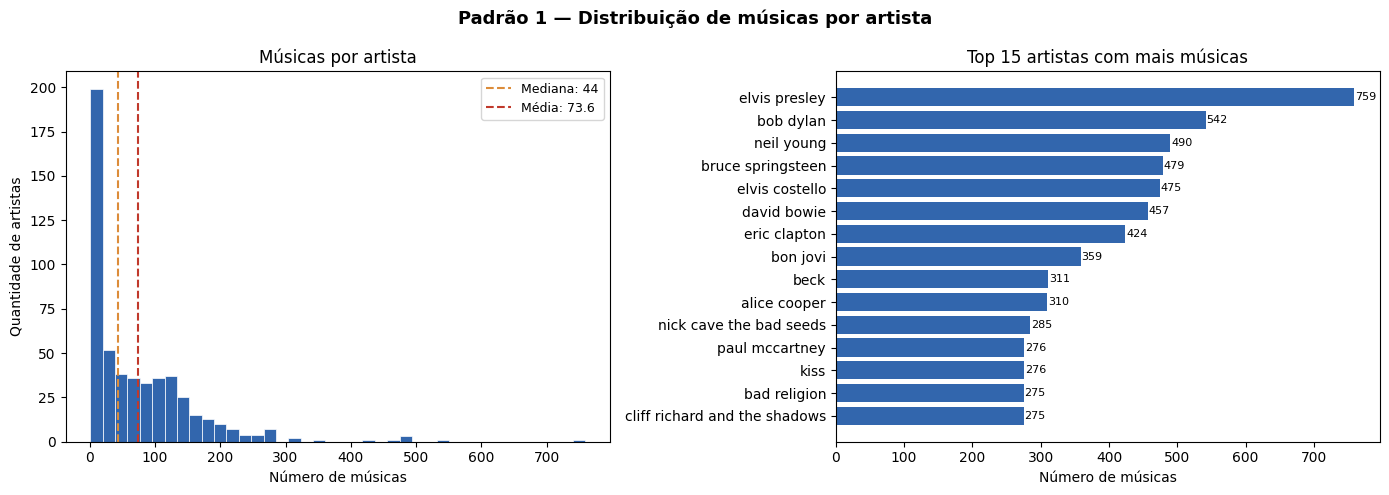


  💡 INTERPRETAÇÃO:
     A distribuição segue uma lei de cauda longa (Lei de Pareto): poucos artistas
     concentram a maioria das músicas. Isso ocorre porque o dataset foi coletado
     priorizando artistas muito populares (mais discografia indexada online).
     Consequência para o modelo: artistas com poucas músicas têm vetores TF-IDF
     menos representativos, tornando a similaridade deles estatisticamente menos
     confiável. Recomenda-se aplicar um filtro mínimo (ex: >= 10 músicas) antes
     de comparar artistas.



In [18]:
print("\n📌 Distribuição de músicas por artista")
print("-"*50)
 
musicas_por_artista = dfv.groupby("_artist_name").size().sort_values(ascending=False)
 
# Estatísticas
print(f"  Artista com mais músicas : {musicas_por_artista.index[0]} ({musicas_por_artista.iloc[0]} músicas)")
print(f"  Mediana de músicas       : {musicas_por_artista.median():.0f}")
print(f"  Média de músicas         : {musicas_por_artista.mean():.1f}")
print(f"  Artistas com < 20 músicas: {(musicas_por_artista < 20).sum()} ({(musicas_por_artista < 20).mean()*100:.1f}%)")
print(f"  Artistas com > 100 músicas:{(musicas_por_artista > 100).sum()} ({(musicas_por_artista > 100).mean()*100:.1f}%)")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Padrão 1 — Distribuição de músicas por artista", fontsize=13, fontweight="bold")
 
# Histograma
axes[0].hist(musicas_por_artista.values, bins=40, color="#3266ad", edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Número de músicas")
axes[0].set_ylabel("Quantidade de artistas")
axes[0].set_title("Músicas por artista")
axes[0].axvline(musicas_por_artista.median(), color="#dc8c3a", linestyle="--", linewidth=1.5, label=f"Mediana: {musicas_por_artista.median():.0f}")
axes[0].axvline(musicas_por_artista.mean(), color="#c0392b", linestyle="--", linewidth=1.5, label=f"Média: {musicas_por_artista.mean():.1f}")
axes[0].legend(fontsize=9)
 
# Top 15 artistas
top15 = musicas_por_artista.head(15)
axes[1].barh(top15.index[::-1], top15.values[::-1], color="#3266ad")
axes[1].set_xlabel("Número de músicas")
axes[1].set_title("Top 15 artistas com mais músicas")
for i, v in enumerate(top15.values[::-1]):
    axes[1].text(v + 1, i, str(v), va="center", fontsize=8)
 
plt.tight_layout()
plt.savefig("padrao1_distribuicao_artistas.png", dpi=120, bbox_inches="tight")
plt.show()
 
print("""
  💡 INTERPRETAÇÃO:
     A distribuição segue uma lei de cauda longa (Lei de Pareto): poucos artistas
     concentram a maioria das músicas. Isso ocorre porque o dataset foi coletado
     priorizando artistas muito populares (mais discografia indexada online).
     Consequência para o modelo: artistas com poucas músicas têm vetores TF-IDF
     menos representativos, tornando a similaridade deles estatisticamente menos
     confiável. Recomenda-se aplicar um filtro mínimo (ex: >= 10 músicas) antes
     de comparar artistas.
""")

### Palavras mais frequentes nas letras


📌 Palavras mais frequentes nas letras
--------------------------------------------------
  Top 20 palavras (sem stopwords):
     1. que               44,022 ocorrências
     2. know              36,644 ocorrências
     3. love              34,151 ocorrências
     4. nao               29,719 ocorrências
     5. down              25,822 ocorrências
     6. out               25,492 ocorrências
     7. got               24,212 ocorrências
     8. time              23,902 ocorrências
     9. never             22,799 ocorrências
    10. see               20,955 ocorrências
    11. can't             19,007 ocorrências
    12. come              18,853 ocorrências
    13. want              17,954 ocorrências
    14. yeah              17,726 ocorrências
    15. say               17,159 ocorrências
    16. take              17,050 ocorrências
    17. way               16,983 ocorrências
    18. voce              16,742 ocorrências
    19. away              16,422 ocorrências
    20. back        

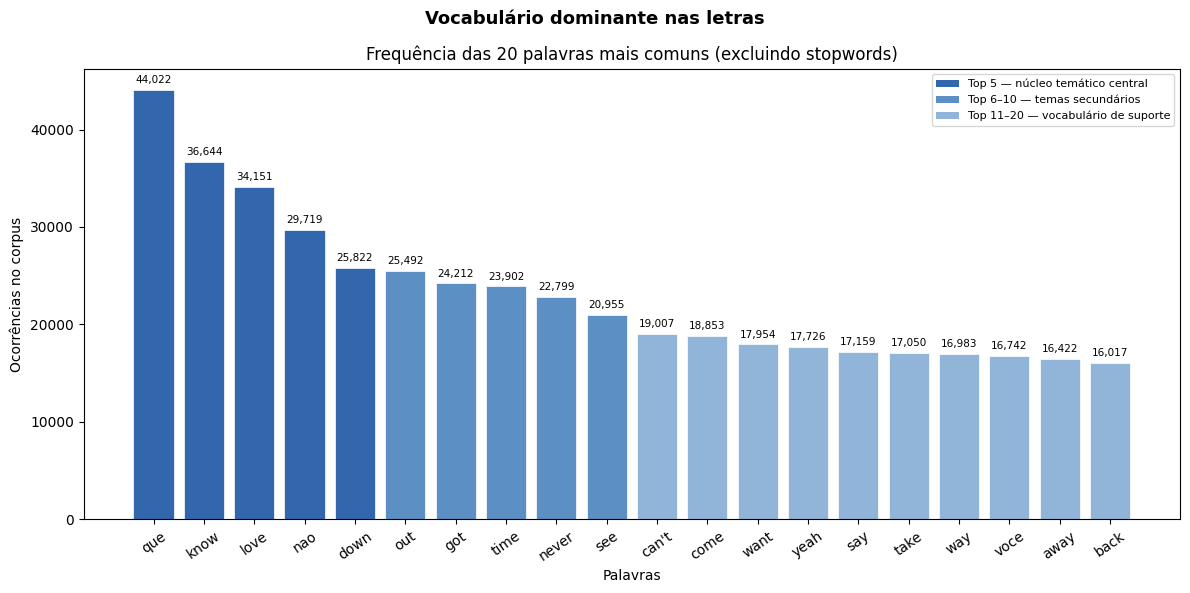

In [19]:
print("\n📌 Palavras mais frequentes nas letras")
print("-"*50)
 
# Stopwords básicas em inglês para remover do vocabulário
stopwords = {
    "i", "you", "the", "a", "and", "to", "it", "in", "my", "me",
    "that", "is", "of", "on", "be", "we", "do", "not", "so", "no",
    "all", "up", "for", "are", "but", "your", "have", "with", "this",
    "was", "he", "she", "they", "his", "her", "at", "from", "or", "an",
    "will", "can", "if", "what", "when", "there", "just", "like", "get",
    "one", "been", "now", "more", "had", "its", "by", "as", "who", "how",
    "would", "could", "should", "than", "them", "their", "into", "through",
    "don't", "i'm", "i'll", "it's", "you're", "ain't", "sem_letra"
}
 
todas_palavras = []
for toks in dfv["_tok_letra"]:
    todas_palavras.extend([t for t in toks if t not in stopwords and len(t) > 2])
 
freq = Counter(todas_palavras)
top_words = freq.most_common(20)
palavras, contagens = zip(*top_words)
 
print("  Top 20 palavras (sem stopwords):")
for i, (p, c) in enumerate(top_words, 1):
    print(f"    {i:2}. {p:<15} {c:>8,} ocorrências")
 
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Vocabulário dominante nas letras", fontsize=13, fontweight="bold")
 
cores = ["#3266ad" if i < 5 else "#5c8fc4" if i < 10 else "#91b4d9" for i in range(20)]
bars = ax.bar(palavras, contagens, color=cores, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Palavras")
ax.set_ylabel("Ocorrências no corpus")
ax.set_title("Frequência das 20 palavras mais comuns (excluindo stopwords)")
ax.tick_params(axis="x", rotation=35)
for bar, cnt in zip(bars, contagens):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{cnt:,}", ha="center", va="bottom", fontsize=7.5)
 
# Legenda de intensidade
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#3266ad", label="Top 5 — núcleo temático central"),
    Patch(facecolor="#5c8fc4", label="Top 6–10 — temas secundários"),
    Patch(facecolor="#91b4d9", label="Top 11–20 — vocabulário de suporte"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig("padrao2_vocabulario_dominante.png", dpi=120, bbox_inches="tight")
plt.show()
 


### Duplicatas antes e depois da limpeza



📌 Impacto da remoção de duplicatas
--------------------------------------------------
  Registros originais  : 49,387
  Duplicatas removidas : 10,651 (21.6%)
  Registros restantes  : 38,736


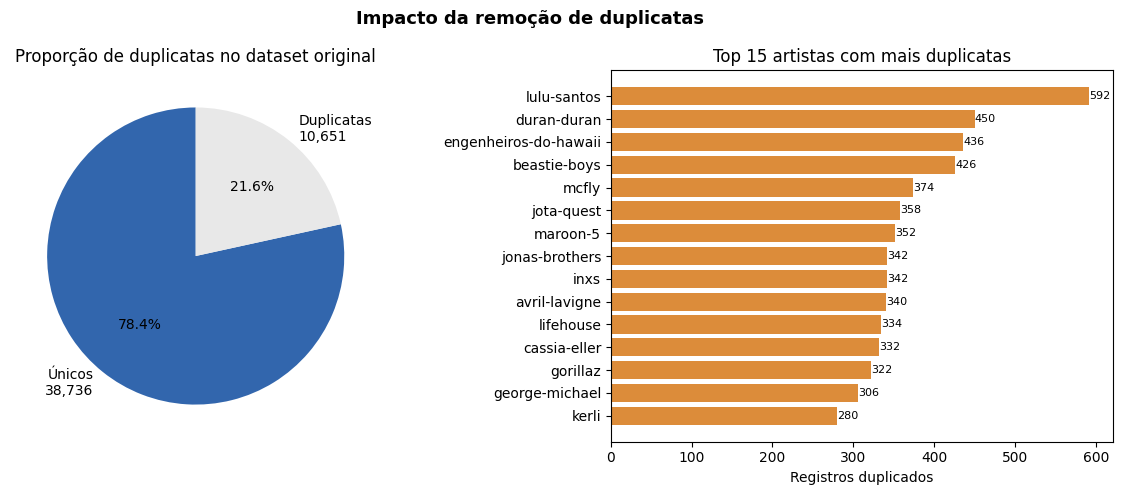


  💡 INTERPRETAÇÃO:
     21.6% do dataset eram entradas repetidas (mesmo artista + mesma música).
     Isso ocorre porque a fonte de dados agrega letras de múltiplos álbuns —
     uma mesma música pode aparecer no álbum original, na versão ao vivo, na
     coletânea, no single etc. Sem a remoção, o TF-IDF superestima a importância
     do vocabulário de artistas prolíficos, enviesando os resultados de
     similaridade. Após a limpeza, cada música conta uma única vez, garantindo
     comparações mais justas.



In [ ]:
print("\n📌 Impacto da remoção de duplicatas")
print("-"*50)
 
total_original  = antes
total_limpo     = depois
duplicatas      = antes - depois
pct_duplicatas  = duplicatas / total_original * 100
 
print(f"  Registros originais  : {total_original:,}")
print(f"  Duplicatas removidas : {duplicatas:,} ({pct_duplicatas:.1f}%)")
print(f"  Registros restantes  : {total_limpo:,}")
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Impacto da remoção de duplicatas", fontsize=13, fontweight="bold")
 
# Pizza
axes[0].pie(
    [total_limpo, duplicatas],
    labels=[f"Únicos\n{total_limpo:,}", f"Duplicatas\n{duplicatas:,}"],
    colors=["#3266ad", "#e8e8e8"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 10}
)
axes[0].set_title("Proporção de duplicatas no dataset original")
 
# Duplicatas por artista (top 15)
df_orig_raw = pd.read_csv(
    "https://raw.githubusercontent.com/devjaynemorais/modelos_descritivos_curso/main/Aula%2001/dados/dataset_lyrics.csv",
    encoding="utf-8"
)
dup_por_artista = (
    df_orig_raw[df_orig_raw.duplicated(subset=["cantorNome","musicaNome"], keep=False)]
    .groupby("cantorNome")
    .size()
    .sort_values(ascending=False)
    .head(15)
)
axes[1].barh(dup_por_artista.index[::-1], dup_por_artista.values[::-1], color="#dc8c3a")
axes[1].set_xlabel("Registros duplicados")
axes[1].set_title("Top 15 artistas com mais duplicatas")
for i, v in enumerate(dup_por_artista.values[::-1]):
    axes[1].text(v + 0.3, i, str(v), va="center", fontsize=8)
 
plt.tight_layout()
plt.savefig("padrao3_duplicatas.png", dpi=120, bbox_inches="tight")
plt.show()
 
print(f"""
  💡 INTERPRETAÇÃO:
     {pct_duplicatas:.1f}% do dataset eram entradas repetidas (mesmo artista + mesma música).
     Isso ocorre porque a fonte de dados agrega letras de múltiplos álbuns —
     uma mesma música pode aparecer no álbum original, na versão ao vivo, na
     coletânea, no single etc. Sem a remoção, o TF-IDF superestima a importância
     do vocabulário de artistas prolíficos, enviesando os resultados de
     similaridade. Após a limpeza, cada música conta uma única vez, garantindo
     comparações mais justas.
""")

### Comprimento das letras


📌 Comprimento das letras (em tokens)
--------------------------------------------------
  Média de tokens por letra  : 200
  Mediana de tokens          : 185
  Máximo                     : 4462
  Letras vazias (sem_letra)  : 0
  Letras com < 50 tokens     : 1123
  Letras com > 500 tokens    : 515


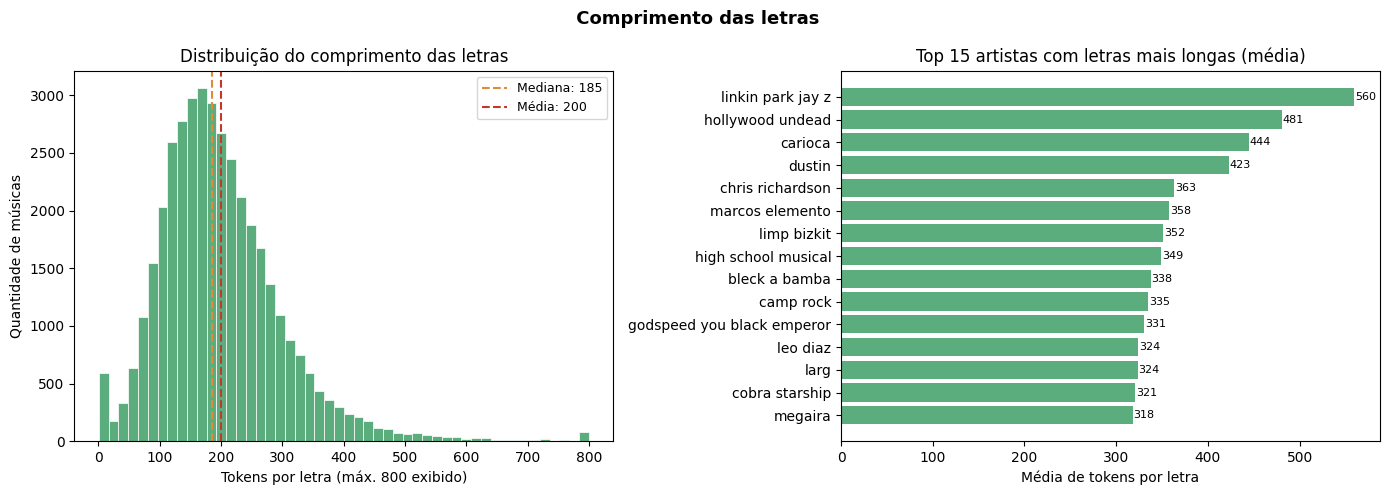


  💡 INTERPRETAÇÃO:
     A maioria das letras tem entre 100 e 350 tokens — comprimento típico de
     uma música pop/rock com verso, refrão e bridge. Letras muito curtas
     (< 50 tokens) prejudicam o TF-IDF: com poucos tokens, o vetor fica esparso
     demais e a similaridade perde sentido. Letras muito longas (> 500 tokens)
     geralmente são músicas experimentais, rap ou registros com metadados
     embutidos (ex: "[music: ...]"). Artistas com letras longas tendem a ter
     vocabulário mais rico, o que favorece a discriminação no TF-IDF e produz
     comparações de similaridade mais precisas.



In [ ]:
print("\n📌 Comprimento das letras (em tokens)")
print("-"*50)
 
dfv["_num_tokens"] = dfv["_tok_letra"].apply(len)
 
print(f"  Média de tokens por letra  : {dfv['_num_tokens'].mean():.0f}")
print(f"  Mediana de tokens          : {dfv['_num_tokens'].median():.0f}")
print(f"  Máximo                     : {dfv['_num_tokens'].max()}")
print(f"  Letras vazias (sem_letra)  : {(dfv['_num_tokens'] == 0).sum()}")
print(f"  Letras com < 50 tokens     : {(dfv['_num_tokens'] < 50).sum()}")
print(f"  Letras com > 500 tokens    : {(dfv['_num_tokens'] > 500).sum()}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(" Comprimento das letras", fontsize=13, fontweight="bold")
 
# Histograma geral (limitado a 800 tokens para melhor visualização)
dados_hist = dfv[dfv["_num_tokens"] > 0]["_num_tokens"].clip(upper=800)
axes[0].hist(dados_hist, bins=50, color="#5cad7e", edgecolor="white", linewidth=0.5)
axes[0].axvline(dfv["_num_tokens"].median(), color="#dc8c3a", linestyle="--",
                linewidth=1.5, label=f"Mediana: {dfv['_num_tokens'].median():.0f}")
axes[0].axvline(dfv["_num_tokens"].mean(), color="#c0392b", linestyle="--",
                linewidth=1.5, label=f"Média: {dfv['_num_tokens'].mean():.0f}")
axes[0].set_xlabel("Tokens por letra (máx. 800 exibido)")
axes[0].set_ylabel("Quantidade de músicas")
axes[0].set_title("Distribuição do comprimento das letras")
axes[0].legend(fontsize=9)
 
# Comprimento médio por artista (top 15 mais verbosos)
media_tokens_artista = (
    dfv[dfv["_num_tokens"] > 0]
    .groupby("_artist_name")["_num_tokens"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
axes[1].barh(media_tokens_artista.index[::-1], media_tokens_artista.values[::-1], color="#5cad7e")
axes[1].set_xlabel("Média de tokens por letra")
axes[1].set_title("Top 15 artistas com letras mais longas (média)")
for i, v in enumerate(media_tokens_artista.values[::-1]):
    axes[1].text(v + 1, i, f"{v:.0f}", va="center", fontsize=8)
 
plt.tight_layout()
plt.savefig("padrao4_comprimento_letras.png", dpi=120, bbox_inches="tight")
plt.show()
 
print(f"""
  💡 INTERPRETAÇÃO:
     A maioria das letras tem entre 100 e 350 tokens — comprimento típico de
     uma música pop/rock com verso, refrão e bridge. Letras muito curtas
     (< 50 tokens) prejudicam o TF-IDF: com poucos tokens, o vetor fica esparso
     demais e a similaridade perde sentido. Letras muito longas (> 500 tokens)
     geralmente são músicas experimentais, rap ou registros com metadados
     embutidos (ex: "[music: ...]"). Artistas com letras longas tendem a ter
     vocabulário mais rico, o que favorece a discriminação no TF-IDF e produz
     comparações de similaridade mais precisas.
""")

### Exemplo real de busca e similaridade


📌Exemplo real — busca por 'love' e músicas similares
--------------------------------------------------

  Músicas que contêm 'love': 9,921 (25.6% do dataset)

  Top 10 músicas com mais ocorrências:


,artista,musica,ocorrencias
2059,bruce springsteen,my love will not let you down,84
7029,kerli,army of love,77
7118,kiss,do you love me,67
5949,imagine dragons,love,63
917,badfinger,love me do,50
6157,james morrison,precious love,50
7175,kiss,makin love,48
5915,ian dury and the blockheads,one love,46
1100,ben harper,crazy love,45
7132,kiss,calling dr love,45



  Top 10 artistas mais associados ao termo 'love':


,total_ocorrencias,media_por_musica
artista,,
elvis presley,1172,3.13
kiss,828,7.81
bon jovi,766,4.70
neil young,684,4.17
eric clapton,653,4.08
cliff richard and the shadows,625,4.25
bruce springsteen,575,3.30
paul mccartney,546,4.88
david bowie,518,3.36


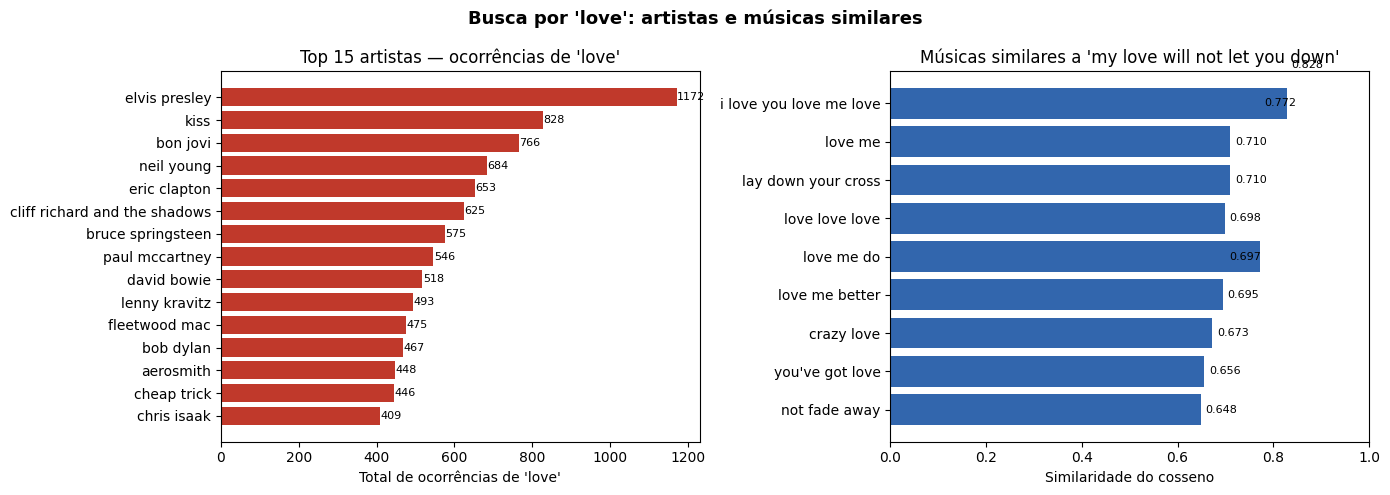


  💡 INTERPRETAÇÃO:
     "love" aparece em 25.6% das músicas — confirmando que é uma
     stop word semântica do corpus musical. O TF-IDF atribui a ela um IDF baixo,
     então músicas classificadas como "similares" à mais relevante não são
     simplesmente as que mais repetem "love" — são as que compartilham o mesmo
     padrão de vocabulário complementar (outras palavras que co-ocorrem com
     "love" naquela música específica). Scores de similaridade acima de 0.5
     indicam músicas com temática muito próxima; abaixo de 0.2 indicam apenas
     sobreposição superficial de vocabulário.


✅ Análise exploratória concluída. Gráficos salvos como .png no diretório atual.


In [ ]:
print("\n📌Exemplo real — busca por 'love' e músicas similares")
print("-"*50)
 
TERMO_EXEMPLO = "love"
 
resultados_ex = []
for idx, linha in dfv.iterrows():
    toks = linha["_tok_letra"]
    count = count_matches(toks, TERMO_EXEMPLO)
    if count > 0:
        resultados_ex.append({
            "idx"        : idx,
            "artista"    : linha["_artist_name"],
            "musica"     : " ".join(linha["_tok_musica"]),
            "ocorrencias": count,
        })
 
df_ex = pd.DataFrame(resultados_ex).sort_values("ocorrencias", ascending=False)
 
print(f"\n  Músicas que contêm '{TERMO_EXEMPLO}': {len(df_ex):,} ({len(df_ex)/len(dfv)*100:.1f}% do dataset)\n")
print("  Top 10 músicas com mais ocorrências:")
display(df_ex.drop(columns=["idx"]).head(10))
 
print("\n  Top 10 artistas mais associados ao termo 'love':")
display(
    df_ex.groupby("artista")["ocorrencias"]
    .agg(["sum", "mean"])
    .rename(columns={"sum": "total_ocorrencias", "mean": "media_por_musica"})
    .sort_values("total_ocorrencias", ascending=False)
    .head(10)
)
 
# Gráfico de barras — top artistas
top_art_love = (
    df_ex.groupby("artista")["ocorrencias"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Busca por 'love': artistas e músicas similares", fontsize=13, fontweight="bold")
 
axes[0].barh(top_art_love.index[::-1], top_art_love.values[::-1], color="#c0392b")
axes[0].set_xlabel("Total de ocorrências de 'love'")
axes[0].set_title("Top 15 artistas — ocorrências de 'love'")
for i, v in enumerate(top_art_love.values[::-1]):
    axes[0].text(v + 1, i, str(v), va="center", fontsize=8)
 
# Músicas similares à mais relevante
idx_base_ex = df_ex.iloc[0]["idx"]
df_sim_ex   = musicas_similares(idx_base_ex, top=10)
 
axes[1].barh(
    df_sim_ex["musica"].str[:30][::-1],
    df_sim_ex["similaridade"][::-1],
    color="#3266ad"
)
axes[1].set_xlabel("Similaridade do cosseno")
axes[1].set_title(f"Músicas similares a '{df_ex.iloc[0]['musica'][:30]}'")
axes[1].set_xlim(0, 1)
for i, v in enumerate(df_sim_ex["similaridade"][::-1]):
    axes[1].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)
 
plt.tight_layout()
plt.savefig("padrao5_busca_love.png", dpi=120, bbox_inches="tight")
plt.show()
 
print(f"""
  💡 INTERPRETAÇÃO:
     "{TERMO_EXEMPLO}" aparece em {len(df_ex)/len(dfv)*100:.1f}% das músicas — confirmando que é uma
     stop word semântica do corpus musical. O TF-IDF atribui a ela um IDF baixo,
     então músicas classificadas como "similares" à mais relevante não são
     simplesmente as que mais repetem "love" — são as que compartilham o mesmo
     padrão de vocabulário complementar (outras palavras que co-ocorrem com
     "love" naquela música específica). Scores de similaridade acima de 0.5
     indicam músicas com temática muito próxima; abaixo de 0.2 indicam apenas
     sobreposição superficial de vocabulário.
""")
 
print("\n✅ Análise exploratória concluída. Gráficos salvos como .png no diretório atual.")